# Condensator Ontwerpopdracht

Bij het vak elektromagnetisme zullen jullie in de eerste paar weken diep ingaan op de elektrostatica. Parallel hieraan zullen we bij het vak DEF-D, naast de fysieke ontwerpopdrachten en colleges, deze simulatie-ontwerpopdracht behandelen. Deze simulatie-opdracht is weer nauw verwoven met de tweede fysieke ontwerpopdracht die in week 3.3 gegeven wordt. Je moet het grootste deel van deze simulatie opdracht afronden voordat je aan de fysieke ontwerpopdracht van week 3.3 begint. Het laatste stuk van deze simulatie opdracht maak je na afloop van de fysieke opdracht. De deadline voor het inleveren van deze simulatie-opdracht is in week 3.4

Je werkt bij deze opdracht in teams die wij indelen. Zoek op Brightspace op met wie je samenwerkt en leg via email contact. Maak goede afspraken over hoe je samen gaat werken.

In deze simulatie opdracht beginnen we met een aantal simulaties van verschillende situaties, die jullie daarna zullen interpreteren. Daarna zal wat essentiële voorbereiding op de tweede fysieke ontwerpopdracht besproken worden. En als laatste zal dieper ingegaan worden op hoe jullie metingen van de tweede ontwerpopdracht afwijken van de theorie.

De opdracht bestaat uit de volgende sub-opdrachten die je moet doen voordat je begint aan de fysieke ontwerpopdracht van week 3.3:
1) Een puntlading in de oorsprong.
2) Een uniform geladen schijf bestaande uit puntladingen.
3) Een geladen schijf op een constant potentiaal.
4) Twee geleidende platen op potentiaal $V_1$ and $-V_1$.
5) Voorbereidende opdracht voor de DEF ontwerpopdracht.

Na de fysieke ontwerpopdracht van week 3.3 kan je ten slotte het laatste deel doen:

6) Reflectie opdracht voor na de fysieke ontwerpopdracht.

De opdracht wordt volledig online gedaan, er zullen hiervoor dus ook geen specifieke werkcolleges voor zijn ingeroosterd. Als jullie vragen hebben kunnen jullie die mailen naar het DEF e-mailadres: DEF-TNW@tudelft.nl. Deze opdracht wordt in week 3.4 beoordeeld en herkansingen zijn in week 3.5, zie de studiehandleiding voor details.
   
Technische Instructies:
- Git clone (als nog niet gedaan) het DEF repo en maak een branch voor werken aan deze opdracht. Nodig je groepsgenoot uit als collaborator. Hiervoor staat een manual op brightspace.
- Dit notebook maakt gebruik van een aantal functies die in het bestand ```functions_electrostatics.py``` staan. Dit bestand moet in dezelfde map (folder) staan als dit notebook. Als je git clone doet, gaat dat automatisch goed, maar verplaats dit notebook dus niet naar een andere map, mail het niet naar een mede-student, etc. Als je niet weet wat een map (folder) en een bestand is, bekijk dan [deze tutorial](https://teachbooks.io/files-and-folders/EN/intro.html).

Onderwijs Instructies:
- Beantwoord de vragen die in dit notebook voor komen direct in dit notebook.
- Als je iets moet printen op het scherm als antwoord op een vraag, doe dit op een gestructureerde manier met als dat relevant is de eenheid erbij, zoals je geleerd is bij het Inleidend Practicum.
- Vermijd 'hardcoden' waar mogelijk.
- Bij elke code cel staat aangegeven of jij hem moet aanpassen of alleen runnen. Lees bij cellen die je moet runnen, maar niet hoeft aan te passen, goed de code door om daarvan te leren en te gebruiken in de cellen die je wel moet aanpassen.

Elektrostatica Opmerkingen:
- In deze opdracht zullen jullie verschillende problemen bestuderen die as-symmetrie hebben. De opdrachten zullen daardoor, cilindrische coördinaten ($r$,$\phi$,$z$) gebruiken, waarbij $r$ de afstand tot de $z$ as is, $z$ de hoogte en $\phi$ de hoek met de $x$-as. Alle gebruikte problemen zullen ook in de $\phi$ richting symmetrisch zijn en die coördinaat zal dus niet uitmaken.
- Voor elke sub-opdracht zal eerst het potentiaal bepaald worden en daarna zal het elektrische veld bepaald worden met de "finite difference" methode. Dit is een methode om de afgeleide te nemen van een dataset. Deze methode is geen onderdeel van de leerdoelen van het vak en komt later in je studie aan bod. We gebruiken "finite difference" hier als gereedschap en als voorbeeld van wat je later nog tegen gaat komen.



Vul de informatie in deze cel in:

| Groep: 60     |  |
| :-------------|:-------------|
| Emma Jule Drent | 6507417 |
| Tim Mekkelholt | 6224687 |

In [1]:
# Run deze cel, pas deze niet aan
import numpy as np
import matplotlib.pyplot as plt
from functions_electrostatics import *
#from IPython import display
from IPython.display import Image, display


epsilon0 = 8.854e-12  # permittiviteit van vacuum (F/m)

"""============================================================================================
We first define the size of the domain of calculation and spatial discretization of the domain
"""

# Grid van het rekendomein; het veld wordt berekend in het (r,z)-vlak (asymmetrie):
width_domain = 5  # (m)
height_domain = width_domain  # maximum afstand van de schijf tot de grond, boven en beneden (m)
grid_step = 0.1  # grid stap grootte (m)

### 1) Een puntlading in de oorsprong

In deze opdracht gaan we in op een numerieke benadering van het potentiaal en elektrische veld rond een puntlading in de oorsprong. 

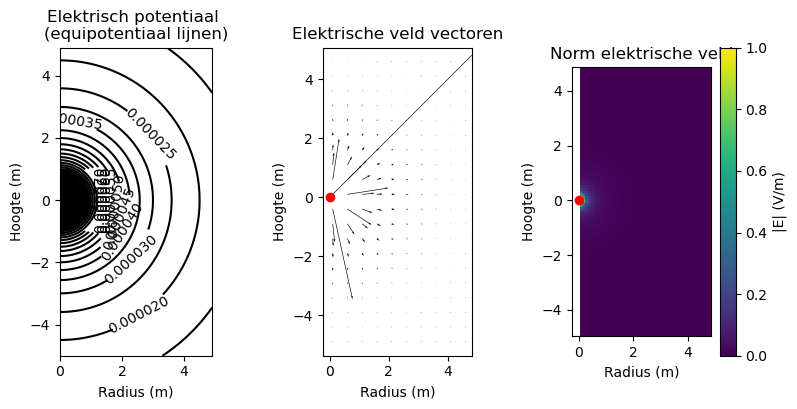

In [2]:
# Run deze cel, pas de cel niet aan
charge_one_point = 1e-14  # lading van 1 punt (C)

r, z, B = initialize_plane_grid_for_pt_charge_at_origin(height_domain, width_domain, grid_step)
V = calculate_V_point_charge_at_origin(charge_one_point, r, z)

Er, Ez, normE = compute_E_pt_charge(V, B, grid_step)  # gebruik de centered finite-difference method
# met Er de r-component, Ez de z-component en normE de norm van het elektrische veld

r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

plot_results_pt_charge_at_origin(Ez, Er, normE, V, r, z, grid_step)


##### Vraag 1a Het potentiaal rond een puntlading

1. Bepaal welke index correspondeert met $z = 0$ m.
2. Plot de log van het potentiaal tegen de log van de straal.
3. Fit de log van het potentiaal met de log van de straal.
4. Print het exponent op een nette manier.

De index die correspondeert met z=0m is 50.


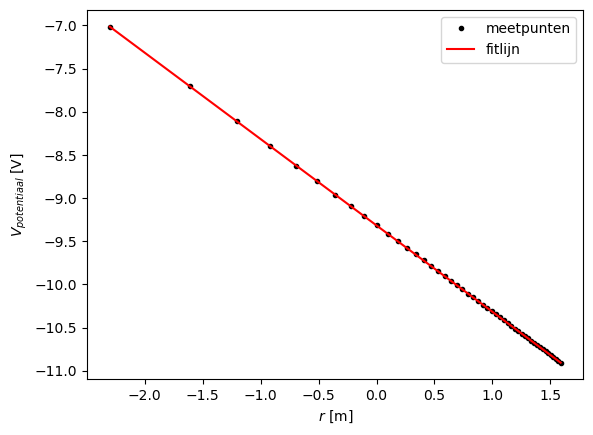

De exponent die uit de fit volgt is -1.0.


In [3]:
from scipy.optimize import curve_fit

# 1) Bepalen van index waar geldt z=0m:
index = find_idx_nearest(z,0)
print(f"De index die correspondeert met z=0m is {index}.")


# 2 en 3) Log-log plot van potentiaal tegen straal + curve_fit. We gaan uit van een verband van V = a*r**b. Deze gaan we logaritmisch fitten, zodanig dat 
# exponent a gevonden kan worden.
def line(x,a,b) :
    return x*a + b

log_r_1a = np.log(r[1:])
log_V = np.log(V[index,1:])     # Uitfilteren van V waarvoor geldt z=0m

val_1a, cov_1a = curve_fit(line, log_r_1a, log_V)       # Curve-fit
a_1a,b_1a = val_1a

x_fit_1a = np.linspace(min(log_r_1a),max(log_r_1a), 1000)
y_fit_1a = line(x_fit_1a,a_1a,b_1a)

#Plotten van figuur:
plt.figure()
plt.plot(log_r_1a,log_V, "k.", label = "meetpunten")
plt.plot(x_fit_1a,y_fit_1a, "r-", label = "fitlijn")
plt.xlabel("$r$ [m]")
plt.ylabel("$V_{potentiaal}$ [V]")
plt.legend()
plt.show()


# 4) Bepalen van de exponent:
print(f"De exponent die uit de fit volgt is {a_1a}.")

##### Vraag 1b Het elektrische veld rond een puntlading
1. Voer van vraag 1a 2 tot 4 uit voor het elektrische veld.

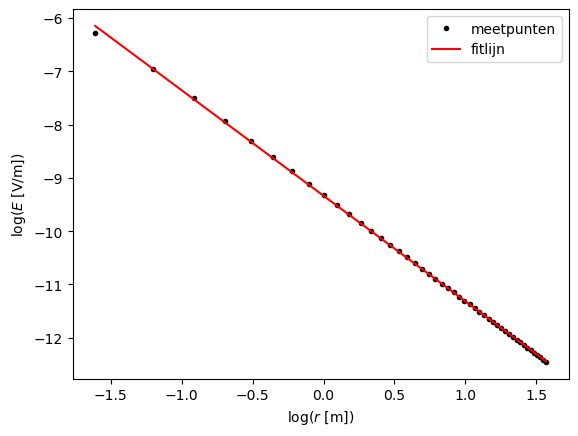

De exponent die uit de fit volgt is -2.0.


In [4]:
E_z0 = normE[index,:]           # Berekenen van het elektrisch veld op z=0m.
E_z0 = np.delete(E_z0,0)            # Verwijderen van punten waar E = 0. Anders volgt een error bij het nemen van een logaritme.
r_for_E = np.delete(r_for_E,0)          # Eveneens verwijderen van punten waarvoor geldt r = 0.


# 2 en 3) Log-log plot van potentiaal tegen straal + curve_fit. We gaan wederom uit van een verband van V = a*r**b en deze wordt logaritmisch gefit.
log_r_1b = np.log(r_for_E)
log_E = np.log(E_z0)

val_1b, cov_1b = curve_fit(line, log_r_1b, log_E)
a_1b,b_1b = val_1b

x_fit_1b = np.linspace(min(log_r_1b),max(log_r_1b), 1000)
y_fit_1b = line(x_fit_1b,a_1b,b_1b)

#Plotten van de figuur:
plt.figure()
plt.plot(log_r_1b,log_E, "k.", label = "meetpunten")
plt.plot(x_fit_1b,y_fit_1b, "r-", label = "fitlijn")
plt.xlabel("log($r$ [m])")
plt.ylabel("log($E$ [V/m])")
plt.legend()
plt.show()

# 4) Bepalen van de exponent:
print(f"De exponent die uit de fit volgt is {a_1b:.1f}.")


### 2) Een uniform geladen schijf bestaande uit puntladingen

In de code hieronder wordt een geladen schijf gemaakt via het superpositie principe. Dit wordt gedaan door een rooster van punten in de ruimte te creëren, alle punten die voldoen aan $z = 0$ m en $r < R$ krijgen een lading charge_one_point en vanuit hier wordt het potentiaal bepaald. Hier is de $z$-as de as van de schijf en de r as de afstand tot de $z$-as.



In [5]:
# In vraag 2.1 wordt naar deze cel verwezen.
disk_radius = 3  # (m)
grid_step = 0.1  # (m)
z_coord_DISK = 0  # (m) positie van de schijf op de z-as
inter_charge_distance = grid_step  # (m) afstand tussen punt ladingen

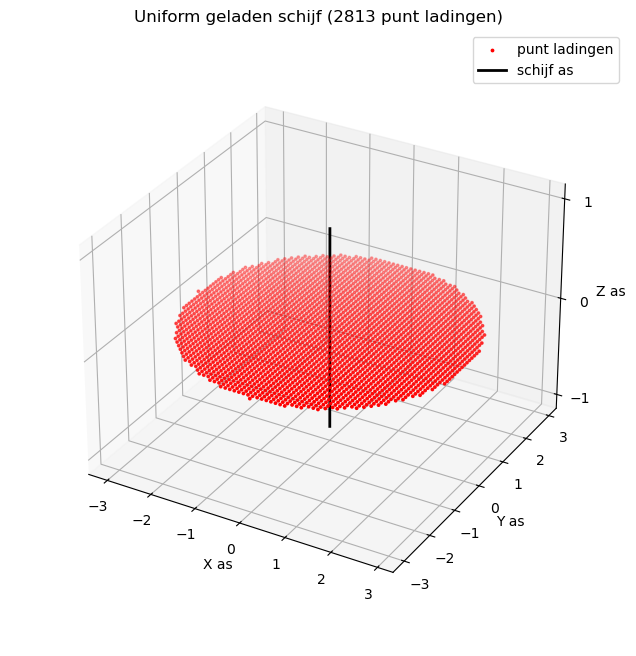

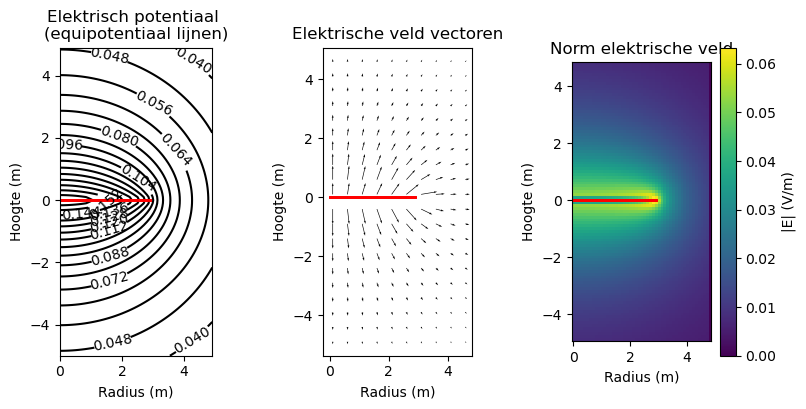

In [6]:
# Kies uit deze cel een van de variabelen en verander die in de cel hierboven pas deze cel zelf niet aan.
r, z, B = initialize_plane_grid_for_uniformly_charged_disk(height_domain, width_domain, grid_step)

idx_z_zero = np.where(abs(z) < 1e-10)[0]
z_coord_DISK = 0  # (m) positie van de schijf op de z-as
inter_charge_distance = grid_step  # (m) afstand tussen punt ladingen

V, number_point_charges_on_disk = calculate_V_disk_at_origin_uniform_surface_charge_density(z_coord_DISK, charge_one_point, disk_radius, inter_charge_distance, r, z)
Er, Ez, normE = compute_E_disk(V, B, grid_step)  # gebruik de centered finite-difference method

r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_coord_DISK, z_coord_DISK)

#### Vraag 2a

In deze vraag gaan jullie achterhalen wat de variabelen die aan het begin van opgave 2 worden geïnitialiseerd betekenen voor de nauwkeurigheid en snelheid van de code.
Pas voor deze vraag de code die net onder het kopje vraag 2 staat aan. Run dan die cel en de cel daaronder opnieuw om het resultaat van je aanpassing te zien.
1. Wat betekent de disk radius variabele die in de bovenste cel geïnitialiseerd wordt, wat gebeurt er als disk radius naar 0 gaat?
2. Wat betekent gridstep en wat voor impact heeft deze variabele op de simulatie?
3. Pak uit de tweede code cel in opdracht 2 een andere variabelen en onderzoek wat deze variabele doet en wat voor impact die heeft op de simulatie.

##### Antwoorden 2a

1. De disk radius variabele is de straal van de geladen schijf. Wanneer deze een waarde van 0 aanneemt, zal in de formule voor het bereken van het potentiaal gedeeld worden door 0. Dit is natuurlijk ongedefinieerd, vandaar de error die volgt als je de code runt.
2. De gridstep is de afstand tussen de puntladingen binnen de schijf. Hoe kleiner de waarde van deze variabele, hoe meer puntladingen geprogrammeerd worden. (Dit betekenent ook dat python meer moet rekenen, en het runnen van de code langer duurt.)
3. "z_coord_DISK" bepaalt de z-coordinaat van de schijf. z_coord_DISK = 0 --> de schijf ligt op de z-as.

#### Vraag 2b Oppervlakte lading

Pas de cel die je in vraag 2a hebt aangepast weer aan naar de originele waardes. Run hierna alle code cellen na vraag 2 weer opnieuw.
Het aantal punten dat gebruikt wordt om de schijf te creëren is number_point_charges_on_disk en de lading van een punt is charge_one_point in Coulomb.
1. Bereken en print de ladingsdichtheid $\sigma$ met een correcte eenheid.

In [7]:
# Uitgaande van het feit dat we te maken hebben met puntladingen en we in het (x,y)-vlak werken, hebben we te maken met het oppervlak om de ladingsdichtheid
# te bepalen.

Oppervlak_schijf = np.pi * disk_radius**2
sigma = charge_one_point * number_point_charges_on_disk / Oppervlak_schijf

print(f"De ladingsdichtheid is {sigma} C/m^2.")

De ladingsdichtheid is 9.948952331500036e-13 C/m^2.


##### Vraag 2c

1. Plot het elektrische potentiaal langs de $r$ as ($z = 0$ m).
2. Plot het potentiaal op de rand van de schijf in hetzelfde figuur $V = \sigma R/(\pi \epsilon_0)$
(bekijk probleem 2.51 in het Griffiths' boek)
3. Plot het potentiaal in het centrum van de schijf in hetzelfde figuur $V = \sigma R/(2 \epsilon_0)$

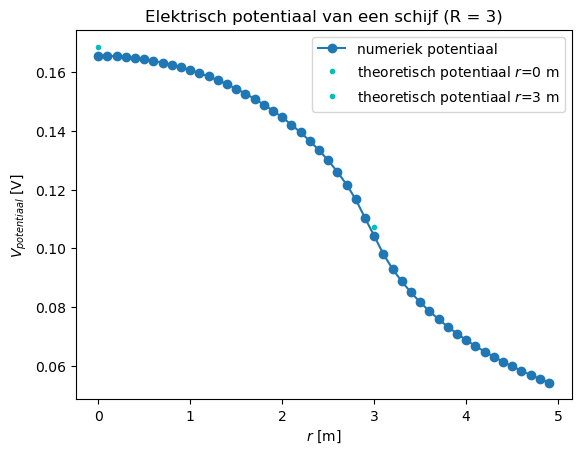

In [8]:
idx_z_zero = find_idx_nearest(z,0)  # Vinden van index waarvoor geldt z=0

V_0 = sigma * disk_radius / (2 * epsilon0) # Potentiaal op r=0
V_R = sigma * disk_radius / (np.pi * epsilon0) # Potentiaal op de straal van de schijf
r_R = disk_radius # Straal van de schijf

# Plotten van de figuur:
plt.title(f"Elektrisch potentiaal van een schijf (R = 3)")
plt.plot(r, V[idx_z_zero], "o-", label="numeriek potentiaal")
plt.plot(0, V_0, "c.", label="theoretisch potentiaal $r$=0 m")
plt.plot(r_R, V_R, "c.", label="theoretisch potentiaal $r$=$3$ m")
plt.legend()
plt.xlabel("$r$ [m]")
plt.ylabel("$V_{potentiaal}$ [V]")
plt.show()

#### Vraag 2d

Het theoretische potentiaal op de as van een hele grote schijf ($R>>z$) is:
$V(z, r=0) = \frac{\sigma}{2\epsilon_0} \big( R - |z|\big)$
zie probleem 2.26 in het Griffiths boek.
1. Plot het numeriek berekend elektrische potentiaal op de $z$-as ($r=0$).
2. Plot het theoretische component van het potentiaal op de as van een schijf met ladingsdichtheid $\sigma$.
3. Sla deze plot op.


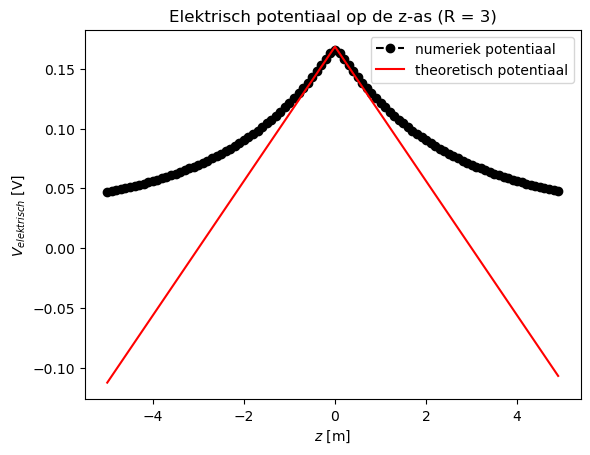

In [9]:
V_theorie = (sigma / (2 * epsilon0)) * (disk_radius - np.abs(z))    # Formule toeppasen

# Plotten van de figuur:
plt.title(f"Elektrisch potentiaal op de z-as (R = {disk_radius})")
plt.plot(z, V[:,0], "ko--", label="numeriek potentiaal")    # Neem de eerste kolom van Ez, corresponderend met r=0.
plt.plot(z, V_theorie, "r-", label="theoretisch potentiaal")
plt.legend()
plt.xlabel("$z$ [m]")
plt.ylabel("$V_{elektrisch}$ [V]")
plt.savefig("Potentiaal_z-as (R = 3)")
plt.show()

#### Vraag 2e

Het theoretische elektrische veld van een oneindig geladen oppervlakte is $|E| = \sigma/(2 \epsilon_0)$ (zie Example 2.5 in het Griffith boek).
1. Plot het z-component van het numeriek berekende elektrische veld op de as van de schijf ($r=0$).
2. Plot het theoretische elektrische veld voor een oneindig geladen oppervlak.
3. Sla deze plot ook op.

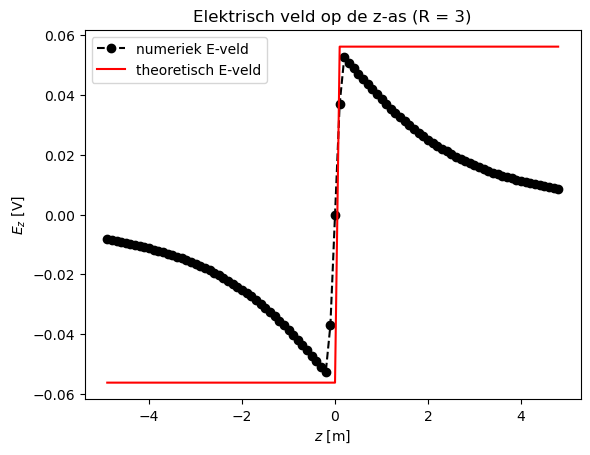

In [10]:
# Berekenen van theoretische waarde d.m.v. formule + aanmaken array:
E_theorie = []
for i in z_for_E:
    if i <= 0:
        E_theorie.append(-sigma / (2*epsilon0))
    else:
        E_theorie.append(sigma / (2*epsilon0))


# Plotten van figuur:
plt.title(f"Elektrisch veld op de z-as (R = {disk_radius})")
plt.plot(z_for_E, Ez[:,0], "ko--", label="numeriek E-veld")           # Neem de eerste kolom van Ez, corresponderend met r=0.
plt.plot(z_for_E,E_theorie, "r-", label="theoretisch E-veld")
plt.legend()
plt.xlabel("$z$ [m]")
plt.ylabel("$E_z$ [V]")
plt.savefig("E-veld_z-as (R = 3)")
plt.show()


#### Vraag 2f
1. Waar benadert het elektrische veld van een uniform geladen schijf dat van een oneindig geladen plaat? 
2. Beschrijf en verklaar de verschillen die je opvallen in de plot die je bij vraag 2e hebt gemaakt.

##### Antwoorden 2f
1. Alleen wanneer het punt dat wordt benaderd (r = 0) op z = 0 (of heel erg in de buurt) zit, zien we dat de numeriek berekende waarde van het elektrisch veld overeenkomt met de theoretische waarde van een oneindig geladen plaat.
2. Bij het numeriek berekende veld zien we dat vanuit z = 0, de waarde van het elektrisch afneemt naarmate de hoogte z toeneemt, terwijl bij de oneindig geladen plaat het elektrisch veld constant is (in de positieve/negatieve z-richting).

#### Vraag 2g

1. Pas helemaal bovenaan in vraag 2 de straal van de schijf aan.
2. Voer dan vragen 2d en 2e opnieuw uit.
3. Voeg de opgeslagen figuren hieronder toe.
4. Beschrijf de verschillen tussen de twee verschillende stralen.

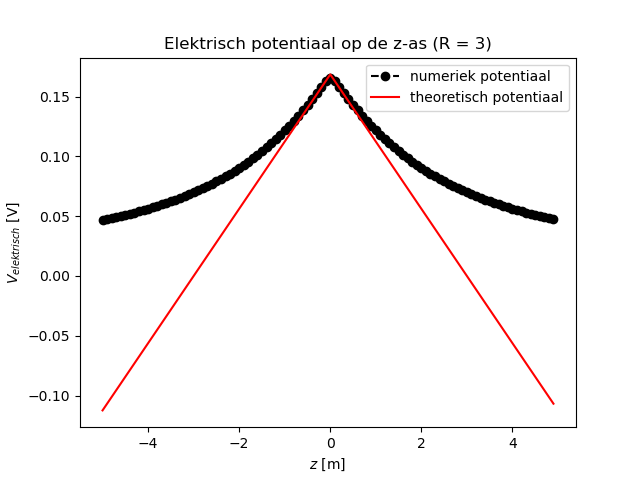

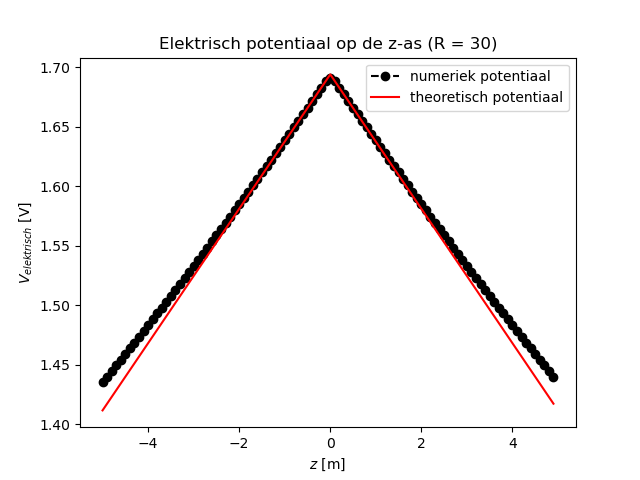

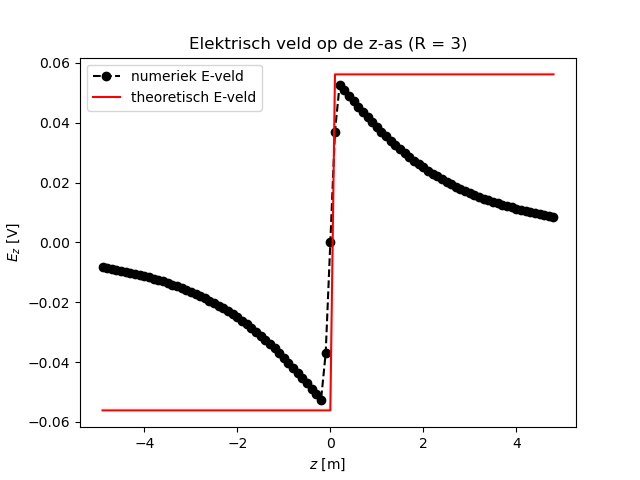

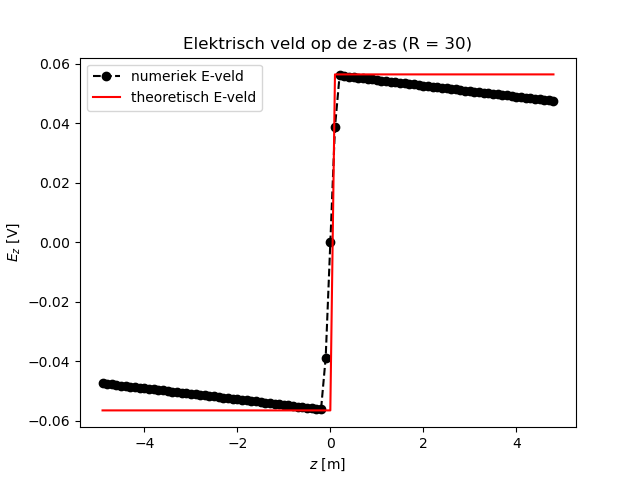

In [11]:
display(Image("Potentiaal_z-as (R = 3).png"))
display(Image("Potentiaal_z-as (R = 30).png"))
display(Image("E-veld_z-as (R = 3).png"))
display(Image("E-veld_z-as (R = 30).png"))

##### Antwoorden 2g

4. Hoe groter de straal, hoe verder je van de oorsprong kan zitten om de theoretische waarde van een oneindig geladen oppervlak te naderen. De theoretische 'fit' past beter op een grotere straal. Dat is logisch, want als R groter en groter wordt, zal hij naar oneindig gaan en het dus een oneindig geladen oppervlak worden.

#### Vraag 2h
Het elektrische veld een afstand $z$ boven het midden van een uniform geladen schijf met een straal $R$ en oppervlakte lading $\sigma$ wordt gegeven door:
$$ \mathbf{E} = \frac{\sigma}{2\epsilon_0} \bigg[ 1- \frac{z}{\sqrt{R^2 + z^2}}\bigg] \hat{\mathbf{z}}$$
Zie probleem 2.6 in het boek van Griffith.

1. Wat moet de hoogte $z$ zijn boven de schijf zodat het elektrische veld door de schijf 10% is in vergelijking met dat van een oneindig geladen plaat?

Voeg hieronder je analytische uitwerking toe.

##### Antwoord 2h

$ \mathbf{E} = \frac{\sigma}{2\epsilon_0} \bigg[ 1- \frac{z}{\sqrt{R^2 + z^2}}\bigg] \hat{\mathbf{z}} = 0.10\frac{\sigma}{2\epsilon_0}$


$1- \frac{z}{\sqrt{R^2 + z^2}}$ = 0.10\
$\frac{z}{\sqrt{R^2 + z^2}}$ = 0.90\
$z = 0.90\sqrt{R^2+z^2}$ \
$z^2 = 0.81R^2 + 0.81z^2$\
$0.19z^2 = 0.81R^2$\
$z^2 = R^2\frac{0.81}{0.19}$\
$z = R\sqrt{\frac{0.81}{0.19}}$


### 3) Een geladen schijf op een constant potentiaal

We zullen nu het verschil bestuderen tussen een uniform geladen schijf en een geleidende schijf die op een bepaald potentiaal gehouden wordt.
De code hieronder lost numeriek de laplace vergelijking op voor een geleidende schijf op een constant potentiaal. Hieruit volgt het potentiaal in de ruimte.

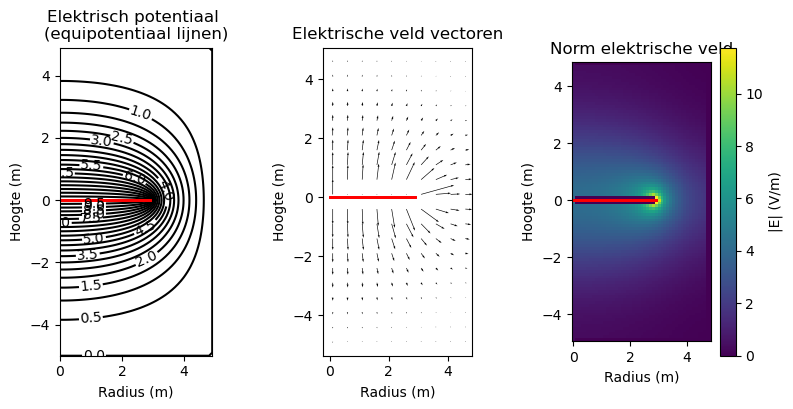

In [12]:
# Run deze cel pas deze niet aan.
V0 = 0  # electric potential at boundary of domain (V)

# Één schijf
z_pos_disk1 = 0  # z-coördinaat van de eerste geleidende schijf (m)
z_pos_disk2 = z_pos_disk1  # z-coördinaat van de tweede geleidende schijf (m)
V1 = 10  # elektrische potentiaal van de eerste geleidende schijf (V)

r, z, r_repmat, V, B, idx_R, idx_z1, idx_z2 = initialize_variables_Laplace(width_domain, disk_radius, height_domain, grid_step, z_pos_disk1, z_pos_disk2, V0, V1, V1)

"""--------------------------------------------------------------------
Veldberekening voor een geleidende schijf
"""
solve_Laplace_equation(V, B, r_repmat, grid_step, idx_z1, idx_z2, idx_R, V1, V1, 1e-3)
Er, Ez, normE = compute_E_disk(V,B,grid_step)
r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

""""---------------------------------------------------------
Plot het berekende veld
"""
plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_pos_disk1, z_pos_disk2)

#### Vraag 3a: De simulatie van het elektrische veld van een geleidende schijf op constant potentiaal

1. Plot de elektrische veld sterkte op de as van de schijf.
2. Print de norm van het elektrische veld op de as heel dicht bij het midden van de schijf, zorg hier voor een nette opmaak.

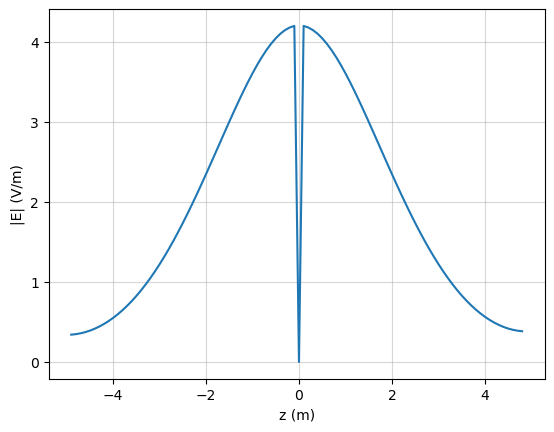

Elektrische veldsterkte op de as (dicht bij het midden van de schijf)
  r ≈ 0.05 m (dichtst bij r=0 op het rooster)
  z ≈ 1.000e-01 m (dichtst bij z=0 op het rooster)
 |E| ≈ 4.2 V/m


In [13]:
#op r=0 is Er=0, dus veldsterkte E is alleen afhankelijk van Ez.
r_mid = 0.5*(r[:-1] + r[1:])
i_axis = np.argmin(np.abs(r_mid)) #dichtst bij r=0
Ez_r0 = Ez[:, i_axis]   
E_r0 = np.abs(Ez_r0)

plt.plot(z_for_E, E_r0)
plt.xlabel("z (m)")
plt.ylabel("|E| (V/m)")
plt.grid(alpha=0.5)
plt.show()

k0 = np.argmin(np.abs(z_for_E))+1

z0 = z_for_E[k0]
r0 = r_mid[i_axis]
E0 = E_r0[k0]

print("Elektrische veldsterkte op de as (dicht bij het midden van de schijf)")
print(f"  r ≈ {r0:.3} m (dichtst bij r=0 op het rooster)")
print(f"  z ≈ {z0:.3e} m (dichtst bij z=0 op het rooster)")
print(f" |E| ≈ {E0:.3} V/m")

#### Vraag 3b: De oppervlakte lading in het midden van een geleidende schijf op constant potentiaal

1. Met welke formule kan je de oppervlaktelading benaderen in het midden van de schijf($r=0$, $z=0$)?
2. Print netjes de benadering van de oppervlakte lading in het midden van de schijf.

##### Antwoord 3b
De randvoorwaarde voor het veld binnen en buiten de geleider:

$$
E_{\perp}^{\text{buiten}} - E_{\perp}^{\text{binnen}} = \frac{\sigma}{\varepsilon_0}
$$

Omdat $E_{\perp}^{\text{binnen}} = 0$ voor een geleider:

$$
\sigma = \varepsilon_0 \, E_{\perp}^{\text{buiten}}
$$

in het midden van de schijf staat het veld al loodrecht op de schijf.
$$
\sigma(0) \approx \varepsilon_0\,\left|E_z(0, 0)\right|
$$

In [14]:
sigma_0 = epsilon0 * E_r0[k0] #k0 geeft de dichtsbijzijnde positieve waarde van z
print(f"Oppervlakteladingsdichtheid in het midden: σ ≈ {sigma_0:.3e} C/m²")

Oppervlakteladingsdichtheid in het midden: σ ≈ 3.720e-11 C/m²


#### Vraag 3c: De oppervlaktelading van een geleidende schijf op constant potentiaal

De oppervlakte lading $\sigma(r)$ van een geleidende schijf met straal $R$ is niet uniform verdeeld over de schijf, maar wordt gegeven door (Problems 2.58 and 2.63 Griffiths 5th edition):
$$\sigma(r) = \frac{Q}{2 \pi R \sqrt{R^2 - r^2}}$$

1. Bereken de totale lading op de schijf met behulp van vraag 3a en 3b.
2. Vergelijk de oppervlakte lading in het centrum van de geleidende schijf met dat van een uniform geladen schijf met dezelfde totale lading.
3. Plot de oppervlakte lading van de geleidende schijf met de berekende lading $Q$, tussen $r = 0$ en $R$.
4. Plot in hetzelfde figuur de oppervlaktelading van een uniform geladen schijf met dezelfde lading $Q$.


1. Totale lading op de schijf: Q ≈ 2.104e-09 C
Uniforme ladingsdichtheid: σ_uniform ≈ 7.441e-11 C/m²
2. In het centrum is σ_geleider(0) ≈ 0.5σ_uniform (dus kleiner).


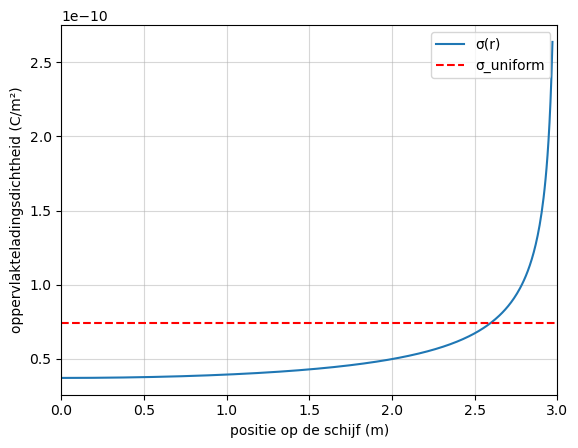

In [15]:
#r=0 invullen en oplossen voor Q geeft:
Q = 2*np.pi*(disk_radius)**2 * sigma_0
print(f"1. Totale lading op de schijf: Q ≈ {Q:.3e} C") #1

#voor een schijf met een uniforme ladingsdichtheid en gelijke Q is de ladingsdichtheid:
sigma_uniform = Q / (np.pi * disk_radius**2)
print(f"Uniforme ladingsdichtheid: σ_uniform ≈ {sigma_uniform:.3e} C/m²")
print(f"2. In het centrum is σ_geleider(0) ≈ {sigma_0/sigma_uniform:.1f}σ_uniform (dus kleiner).") #2

def sigma(r):
    return Q / (2 * np.pi * disk_radius * np.sqrt(disk_radius**2 - r**2))

r_plot = np.linspace(0, disk_radius*(0.99), 500)  # stopt net onder R

plt.figure()
plt.plot(r_plot, sigma(r_plot), label="σ(r)") #3
plt.xlabel("positie op de schijf (m)")
plt.ylabel("oppervlakteladingsdichtheid (C/m²)")
plt.grid(alpha=0.5)
plt.xlim(0, disk_radius)
plt.axhline(y=sigma_uniform, color='r', linestyle='--', label='σ_uniform') #4
plt.legend()
plt.show()

#### Vraag 3d: Het edge effect

1. Bepaal het maximum elektrische veld door de geleidende schijf in de simulatie.
2. Bepaal waar in de ruimte dit maximum zich bevindt.
3. Hoeveel hoger is dit maximum dan het elektrische veld in het midden van de schijf?
4. Print met een nette opmaak de waardes die je hier hebt berekend.
5. Leg uit wat de oorzaak van dit lokaal hoge elektrische veld is?


In [16]:
E_abs = np.sqrt(Er**2 + Ez**2) #Deze keer Er meenemen in de berekening omdat het om het hele veld gaat.
Emax = np.nanmax(E_abs)

iz_max, ir_max = np.unravel_index(np.nanargmax(E_abs), E_abs.shape)
z_max = z_for_E[iz_max]
r_max = r_mid[ir_max]

i_axis = np.argmin(np.abs(r_mid))                 #dichtst bij r=0 
k_plus = np.where(z_for_E > 0)[0][0]              #eerste punt boven z=0

E_center = E_abs[k_plus, i_axis]                   #E net boven het midden
factor = Emax / E_center

print(f"1. Maximum veldsterkte: |E|_max = {Emax:.3} V/m")
print(f"2. Locatie maximum: r ≈ {r_max:.3} m, z ≈ {z_max:.3} m")
print(f"3. De maximale veldsterkte is ongeveer {Emax/E0:.1f} keer groter dan de veldsterkte in het midden van de schijf.") #3

1. Maximum veldsterkte: |E|_max = 11.8 V/m
2. Locatie maximum: r ≈ 2.95 m, z ≈ 0.1 m
3. De maximale veldsterkte is ongeveer 2.8 keer groter dan de veldsterkte in het midden van de schijf.


##### Antwoord 3d.5

Bij een geleider verplaatst lading zich zodat het oppervlak equipotentiaal blijft. Door de scherpe rand (kleine kromtestraal) hopen lading en veldlijnen zich daar op: σ(r) wordt groot richting r→R. Omdat vlak buiten de geleider $E_\perp=\sigma/\varepsilon_0$, is het elektrische veld bij de rand veel groter dan in het midden.

### 4) Twee geleidende platen op potentiaal $V_1$ and $-V_1$

In de cel hieronder wordt weer op dezelfde manier als in opdracht 3 de laplace vergelijking van deze situatie opgelost.

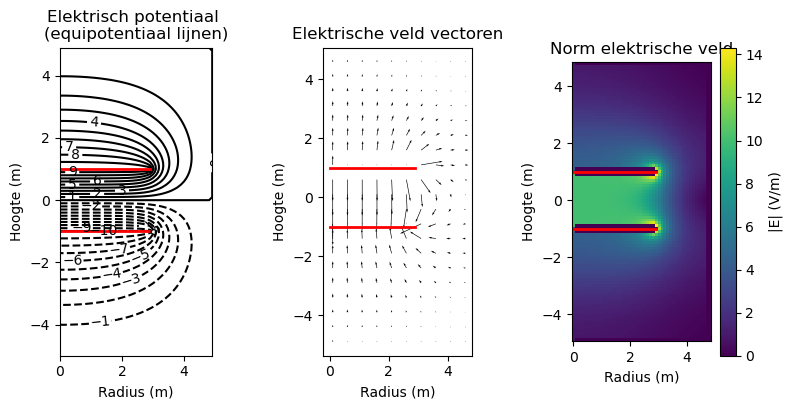

In [17]:
# Run deze cel en pas de cel aan in vraag 4f.
# Voor twee schijven
spacing_between_disks = 2  # (m)
z_pos_disk1 = spacing_between_disks/2  # z-coördinaat van de eerste geleidende schijf (m)
z_pos_disk2 = -spacing_between_disks/2  # z-coördinaat van de tweede geleidende schijf (m)
V1 = 10  # elektrische potentiaal van de eerste geleidende schijf (V)
V2 = -10  # elektrische potentiaal van de tweede geleidende schijf (V)

r, z, r_repmat, V, B, idx_R, idx_z1, idx_z2 = initialize_variables_Laplace(width_domain, disk_radius, height_domain, grid_step, z_pos_disk1, z_pos_disk2, V0, V1, V2)

"""--------------------------------------------------------------------
Veldberekening voor de twee geleidende schijven
"""
solve_Laplace_equation(V, B, r_repmat, grid_step, idx_z1, idx_z2, idx_R, V1, V2, 1e-3)
Er, Ez, normE = compute_E_disk(V, B, grid_step)
r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

""""---------------------------------------------------------
Plot het berekende veld
"""
plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_pos_disk1, z_pos_disk2)



#### Vraag 4a: Het $z$-component van het numeriek berekende elektrische veld van twee geleidende platen

1. Plot het $z$-component van het numeriek berekende elektrische veld op de as van de schijven.


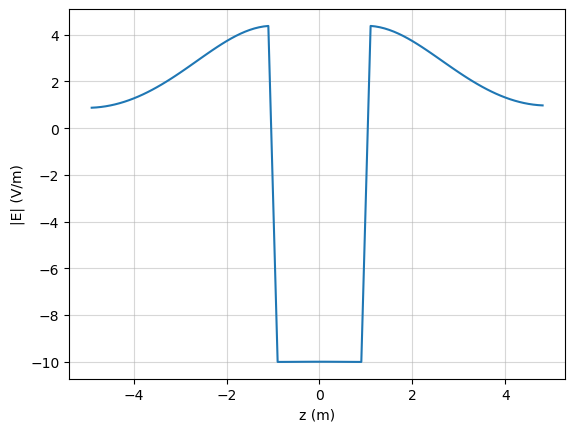

In [18]:
r_mid = 0.5*(r[:-1] + r[1:])
i_axis = np.argmin(np.abs(r_mid)) #index voor de waarde dichtst bij r=0
Ez_r0 = Ez[:, i_axis]   
Eabs = np.sqrt(Ez**2 + Er**2)

plt.plot(z_for_E, Ez_r0)
plt.xlabel("z (m)")
plt.ylabel("|E| (V/m)")
plt.grid(alpha=0.5)
plt.show()

k0 = np.argmin(np.abs(z_for_E))+1

#### Vraag 4b: Verschillen tussen verschillende configuraties

1. Gegeven het potentiaal tussen twee geleidende platen, wat is het theoretische elektrische veld in elke regio? Laat dit zien met een afleiding en een schets die de verschillende regio's aangeeft.
2. Beschrijf het numeriek berekende elektrische veld op de as van de schijven, komt dit overeen met het theoretische elektrische veld?
3. Vergelijk het numeriek berekende elektrische veld tussen de twee schijven ($r=0$ and $z=0$) met dat van een enkele geleidende schijf op hetzelfde potentiaal(vraag 3a), welk voordeel heeft deze configuratie?

##### Antwoorden 4b

1. Buiten de platen (z > d/2 en z < -d/2) is het elektrische veld in het ideale model van oneindig grote platen nul. Dit komt doordat de veldbijdragen van de twee platen daar elkaar opheffen: boven de bovenste plaat wijst het veld van de +plaat naar buiten, terwijl de bijdrage van de -plaat juist de tegengestelde richting heeft (en omgekeerd onder de onderste plaat). Tussen de platen versterken de bijdragen elkaar, waardoor het veld daar ongeveer uniform is met grootte $ |E| \approx \Delta V/d $ en richting van $+V$ naar $-V$. In de numerieke simulatie met eindige schijven is $E$ buiten niet exact nul door randvelden, maar het wordt wel duidelijk kleiner dan tussen de platen.

![schets](meesterwerk.png)

2. Net als bij het theoretisch elektrische veld is bij het numeriek berekende veld een constant elektrisch veld te vinden. Boven en onder de schijven zitten er wel verschillen. Het theoretische veld stelt dat het veld daar 0 moet zijn, maar dat is hier niet het geval. Hoewel het veld duidelijk minder sterk is dan tussen de platen. Is het geen 0.

3. Bij één schijf is het veld op de as niet uniform: |E| verandert sterk met z en wordt snel kleiner verder van de schijf. Bij twee schijven ontstaat tussen de platen een duidelijk plateau (bijna constant |E|), zoals bij een ideale plaatcondensator. Voordeel: het veld tussen de platen is veel uniformer en daardoor beter voorspelbaar/bruikbaar dan bij één schijf.

#### Vraag 4c: De capaciteit tussen twee geleidende platen

1. Bepaal de verwachte oppervlakte lading op de binnenzijde van een van de schijven.
2. Bepaal de verwachte totale lading op beide schijven.
3. Bepaal de capaciteit van deze situatie.
4. Print alle bepaalde waardes op een nette en overzichtelijke manier.

In [19]:
DeltaV = V1 - V2 
d = spacing_between_disks

#verwacht uniform veld tussen de platen
E_theory = DeltaV / d

#verwachte oppervlakteladingsdichtheid op de binnenzijde
sigma_in = epsilon0 * E_theory
print(f"E ≈ ΔV/d = {E_theory:.3} V/m")
print(f"1. σ_binnen ≈ ε0 E = {sigma_in:.3e} C/m²")

Q_total = 2 * sigma_in * np.pi * disk_radius**2
print(f"2. De totale lading op beide schijven is Q_total ≈ {Q_total:.3e} C")

Capacity = Q_total / (DeltaV * 2) #factor 2 in de noemer om van 2 schijven naar 1 te gaan
print(f"3. De capaciteit van de plaat is C ≈ {Capacity:.3e} C/V")

E ≈ ΔV/d = 10.0 V/m
1. σ_binnen ≈ ε0 E = 8.854e-11 C/m²
2. De totale lading op beide schijven is Q_total ≈ 5.007e-09 C
3. De capaciteit van de plaat is C ≈ 1.252e-10 C/V


#### Vraag 4d: Theoretische oppervlakte lading

1. Is de oppervlaktelading aan de buitenkant van de schijven gelijk aan nul, beargumenteer waarom wel of niet.
2. Wat is het elektrische veld nabij het oppervlak van een geleider?

##### Antwoorden 4d

1. In het theoretische model is de oppervlaktelading aan de buitenkant gelijk aan 0. In dat model is er aan de buitenkant geen veld waardoor er ook geen oppervlakte lading is. In het numeriek berekende model is er wel een veld, waardoor de oppervlaktelading niet gelijk is aan 0.

2. Vlak boven een geleider is de magnitude van het veld gelijk aan de loodrechte component (tangentiele component = 0). En binnen een geleider is het elektrisch veld gelijk aan 0. dus voor het elektrisch veld nabij een geleider geldt:
$$E_\perp^{\text{buiten}} = \frac{\sigma}{\varepsilon_0}$$

#### Vraag 4e: Numeriek berekende ladingsdichtheid

1. Welke waarde heeft het $z$-component van het elektrische veld, op de as van de schijf net onder de onderste schijf.
2. Wat is volgens de formule uit vraag 4d 2 de ladingsdichtheid aan de onderkant van de onderste geleidende plaat.
3. Welke waarde heeft het $z$-component van het elektrische veld, op de as van de schijf net boven de onderste schijf.
4. Wat is volgens de formule uit vraag 4d 2 de ladingsdichtheid aan de bovenkant van de onderste geleidende plaat.
5. Print de bepaalde waardes op een nette en overzichtelijke manier.

In [20]:
# index net onder en net boven de plaat
k_below = np.where(z_for_E < z_pos_disk2)[0][-2]
k_above = np.where(z_for_E > z_pos_disk2)[0][0]

Ez_below = Ez_r0[k_below]
Ez_above = Ez_r0[k_above]

sigma_below = epsilon0 * Ez_below
sigma_above = epsilon0 * Ez_above

print(f"1. Net onder de plaat: z={z_for_E[k_below]:.3} m, Ez={Ez_below:.3} V/m")
print(f"2. σ_onderkant ≈ ε0 · Ez = {sigma_below:.3e} C/m²")
print(f"3. Net boven de plaat: z={z_for_E[k_above]:.3} m, Ez={Ez_above:.3} V/m")
print(f"4. σ_bovenkant ≈ ε0 · Ez = {sigma_above:.3e} C/m²")


1. Net onder de plaat: z=-1.1 m, Ez=4.38 V/m
2. σ_onderkant ≈ ε0 · Ez = 3.875e-11 C/m²
3. Net boven de plaat: z=-0.9 m, Ez=-10.0 V/m
4. σ_bovenkant ≈ ε0 · Ez = -8.858e-11 C/m²


#### Vraag 4f: Conclusies over de ladingsdichtheid op de twee schijven

1. Wat kan je uit vraag 4d en e concluderen over de daadwerkelijke lading op een schijf in tegenstelling tot de berekende lading in vraag 4c?
2. Wat is de invloed hiervan op de capaciteit berekend in vraag 4c?
3. Run de cel net onder het kopje vraag 4 opnieuw, maar dan met een kleinere afstand tussen de schijven, wat verandert er?

##### Antwoorden 4f

1. Niet alle lading zit aan de binnenkant. Er zit ook lading aan de buitenzijden van de schijven, waardoor de totale lading afwijkt van het theoretische model.
2. Door de lading aan de buitenkant, kan Q groter uitvallen dan voorspeld, wat dus ook de capaciteit groter maakt dan in de eerdere berekening.
3. Het veld tussen de schijven wordt groter. Ook komt er een relatief grotere hoeveelheid van de lading op de binnenkant, wat het meer doet lijken op het theoretische model.

### 5) Voorbereidende opdracht voor de fysieke DEF ontwerpopdracht

In deze vraag zullen we ingaan op benodigde voorkennis voor de fysieke ontwerpopdracht "Maak een sensor met condensatoren". De formules die je in deze opdracht opstelt, heb je nodig gedurende de fysieke ontwerpopdracht.

In deze vraag zullen we kijken naar de ideale vlakke plaat condensator. Als de afstand tussen de platen veel kleiner is dan de grootte van de platen dan wordt de aanname gemaakt dat het veld tussen de platen constant is. Deze aanname zal niet helemaal overeenkomen met de werkelijkheid, zoals je in deze opdracht en de fysieke DEF ontwerpopdracht achter zal komen.

#### Vraag 5a: Functies voor de capaciteit van enkele opdrachten

1. Vind de formule voor de capaciteit van een vlakke plaat condensator en een cilinder condensator, onder de aanname dat de afstand tussen de platen veel kleiner is dan het oppervlakte van de condensator (vlakke plaat aanname).
2. Schrijf een python functie die de relevante parameters als input neemt en de capaciteit van een vlakke plaat condensator als output heeft.
3. Vind de formule voor de capaciteit van een cilinder condensator onder de aanname dat de afstand tussen de binnen en buiten wand klein is.
4. Schrijf een python functie die de relevante parameters als input neemt en de capaciteit van een cilinder condensator als output heeft.

In [21]:
"""
Algemeen:
Voort het elektrisch veld geldt: E * A = Q_enc / (epsilon0 * epsilonr) (wet van Gauss in integraalvorm).
V = E * d = Q_enc / (A * epsilon0 * epsilonr) (Elektrisch potentiaal integreren over vlak oppervlak).
Capaciteit C = Q_enc / V = epsilon0 * epsilonr * A / d.
"""


# Functie bepaling C (vlakke plaat):
def vlakkeplaat(epsilonr,A,d):
    C = epsilon0 * epsilonr * A / d     # Afstand tussen de twee platen << oppervlakte A platen. 
    return C


"""
De exacte formule voor een cilinder condensator is C = 2*pi*epsilon*L/ ln(buitenstraal/binnenstraal), maar omdat we nu uitgaan van het feit dat de dikte van de cilinder zeer klein
is, nemen we i.p.v. ln(R_buiten / R_binnen) ---> (R_buiten - R_binnen) / R_binnen. Daaruit volgt de aproximatie C = 2*pi*epsilon*L*R_binnen/(R_buiten-R_binnen).
"""

# Functie bepaling C (cilinder):
def cilinder(epsilonr,L,R_buiten,R_binnen):
    C = 2 * np.pi * epsilon0 * epsilonr * L * R_binnen / (R_buiten - R_binnen)
    return  C

#### Vraag 5b: Capaciteit van enkele simpele condensatoren

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.
Hieronder staan een aantal condensatoren waarvoor jullie de capaciteit gaan berekenen. Print de capaciteit van elke condensator op een nette en overzichtelijke manier.
1. Bereken de capaciteit van een condensator gemaakt van twee vierkante plaatjes van 10 bij 10 cm met een plaatafstand van 1 mm en lucht als medium?
2. Bereken de capaciteit van een cilinder condensator met een binnendiameter van 9 mm en een buitendiameter van 10 mm met een lengte van 10 cm en lucht als medium?
3. Bereken de capaciteit van de condensatoren als de afstand tussen de platen verdubbeld
4. Bereken de capaciteit van de condensatoren uit 1 en 2 hierboven beschreven als ze gevuld zijn met water.
5. Bereken de capaciteit van de condensatoren uit 1 en 2 hierboven als de holte gevuld is met PVC.


In [22]:
# 1) Vlakke plaat condensator:
A1 = 10*0.01 * 10*0.01              # (m^2) oppervlakte plaat
d1 = 1*0.001                        # (m) plaatafstand
epsilonr_lucht = 1.00056            # (F/m)                         *Internet geraadpleegd*
C1 = vlakkeplaat(epsilonr_lucht,A1,d1)
print(f"1. Vlakke plaat condensator: C = {C1} F")


# 2) Cilinder condensator:
R_binnen2 = (9/2)*0.001             # (m) straal van binnenste cilinder
R_buiten2 = (10/2)*0.001            # (m) straal van buitenste cilinder
L2 = 10*0.01                        # (m) lengte van condensator
C2 = cilinder(epsilonr_lucht,L2,R_buiten2,R_binnen2)
print(f"2. Cilinder condensator: C = {C2} F")


# 3) Afstand tussen platen verdubbeld:
C3a = vlakkeplaat(epsilonr_lucht,A1,2*d1)                              # Afstand d 2x zo groot t.o.v. vraag 1
C3b = cilinder(epsilonr_lucht,L2,R_buiten2+(0.5*0.001),R_binnen2)      # Afstand tussen binnen- en buitenstraal 2x zo groot -> buitenstraal is 0.5 mm groter t.o.v. vraag 2
print(f"3. Afstanden verdubbeld: C = {C3a} F (vlakke plaat) en C = {C3b} F (cilinder)")


# 4) Vulling = water:
epsilonr_water = 78.5       # (F/m)                                 *Internet geraadpleegd*
C4a = vlakkeplaat(epsilonr_water,A1,d1)
C4b = cilinder(epsilonr_water,L2,R_buiten2,R_binnen2)
print(f"4. Water: C = {C4a} F (vlakke plaat) en C = {C4b} F (cilinder)")


# 5) Vulling = PVC:
epsilonr_PVC = 4.5          # (F/m)                                 *Internet geraadpleegd*
C5a = vlakkeplaat(epsilonr_PVC,A1,d1)
C5b = cilinder(epsilonr_PVC,L2,R_buiten2,R_binnen2)
print(f"5. PVC: C = {C5a} F (vlakke plaat) en C = {C5b} F (cilinder)")

1. Vlakke plaat condensator: C = 8.858958239999999e-11 F
2. Cilinder condensator: C = 5.009622862543701e-11 F
3. Afstanden verdubbeld: C = 4.4294791199999996e-11 F (vlakke plaat) en C = 2.5048114312718507e-11 F (cilinder)
4. Water: C = 6.950389999999999e-09 F (vlakke plaat) en C = 3.930352949445116e-09 F (cilinder)
5. PVC: C = 3.9842999999999994e-10 F (vlakke plaat) en C = 2.2530685697456085e-10 F (cilinder)


#### Vraag 5c: Condensatoren uit het dagelijkse leven

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.
Hieronder is een foto te zien van condensatoren die in het dagelijkse leven gebruikt wordt.
Print de capaciteiten in deze vraag op een nette en overzichtelijke manier.
1. In figuur 5.1 is een condensator te zien van 1 $\micro$F, stel deze condensator kan geapproximeerd worden als een cilinder condensator met binnendiameter 5 mm en een buitendiameter van 6 mm. Bereken wat de lengte van de condensator dan zou zijn.
2. Stel dat we een vierkante plaat condensator hebben van 1 $\micro$F. Bereken hoe lang de vlakke plaat condensator moet zijn als er 0.5 mm tussen de platen zit en de platen 6 mm breed zijn.

![figure 5.1](figures/Condensator_1_uF.jpg)

##### Figure: 5.1 Een 1 microfarad condensator.

In [23]:
# 1) Cilindrische condensator:
L_cilinder = 1e-6 * (6e-3 - 5e-3) / (2 * np.pi * epsilon0 * epsilonr_lucht * 5e-3)  # Herschrijven functie uit 5.1 + invullen waarden 
print(f"De lengte van de cilinder condensator is {L_cilinder} m.")


# 2) Vlakke plaat condensator:
A_plaat = 1e-6 * 0.5e-3 / (epsilon0 * epsilonr_lucht)   # Herschrijven functie uit 5.1 + invullen waarden
L_plaat = A_plaat / 0.006 
print(f"De lengte van de vlakke plaat condensator is {L_plaat} m.")

De lengte van de cilinder condensator is 3593.0848476805863 m.
De lengte van de vlakke plaat condensator is 9406.674134331775 m.


#### Vraag 5d: Hoge capaciteit condensatoren

1. Beargumenteer of je antwoorden uit vraag 5c realistisch zijn.
2. Bekijk je formule uit vraag 5a en bedenk hoe ze dit binnen in de condensator opgelost hebben.

##### Antwoorden 5d

1. De berekende lengtes van de condensatoren zijn erg groot en daarmee niet realistisch (en rendabel). De condensator op de foto is overduidelijk niet duizenden meters lang.
2. De gebruikte vulling is niet lucht, maar een andere stof met een hogere permittiviteit. Dan nog zou de lengte heel groot moeten zijn, dus het is waarschijnlijk dat in werkelijkheid de dikte d of de afstand tussen binnen- en buitendiameter, veel kleiner is.

#### Vraag 5e: Condensator in een achtbaan

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.

Met het vak inleidend practicum zijn jullie naar Drievliet gegaan om daar metingen aan de attracties te doen. In Drievliet staat de achtbaan Formule X, deze achtbaan heeft een topsnelheid van 70 $\frac{\text{km}}{\text{h}}$ en bevat een treintje met plek voor 6 mensen. Deze snelheid bereikt de achtbaan door heel snel een karretje weg te schieten, dit wordt gedaan door de treintjes met een lineaire inductie motor te versnellen. Om de impact hiervan op het stroomnet te beperken gebruiken zij een condensator om de energie op te slaan en dan in een keer af te staan aan het treintje. In deze opdracht gaan we kijken wat de afmetingen zouden moeten zijn als ze vlakke plaat condensatoren zouden gebruiken.

De energie die opgeslagen is in een condensator kan berekend worden met de onderstaande formule.

$E = \frac{1}{2} CV^2$
Hierin is $E$ de totaal opgeslagen energie $C$ de capaciteit en $V$ het voltage waarop de condensator opereert, in dit geval $10$ $kV$.
1. Schat de massa van een treintje dat afgeschoten wordt.
2. Bereken de totale energie van het treintje na het afschieten.
3. Bereken de totale capaciteit van de condensator.
4. Bereken het oppervlakte van een vlakke plaat condensator die deze capaciteit heeft als die gevuld is met water en de platen 1 mm van elkaar afstaan.
5. Print alle berekende waardes op een nette en overzichtelijke manier.
6. Is dit realistisch, bedenk een manier hoe dit toch kan in een relatief klein volume.


In [24]:
# 1) Neem aan gemiddelde persoonsmassa van 70 kg (voornamelijk kinderen + volwassen). Massa van het karretje is circa 800 kg. Optellen:
m_trein = 70 * 6 + 800     # (kg)
print(f"1. De geschatte massa van het treintje is {m_trein} kg.")

# 2) Gebruikmaken van E_kin = 1/2mv^2:
v_max = 70/3.6      # (m/s) maximale snelheid
E_kin = m_trein * v_max**2  # (J) kinetische energie
print(f"2. De kinetische energie van het treintje op maximale snelheid is {E_kin} J.")

# 3) Bereken capaciteit:
V_condensator = 10e3    # (V) voltage over condensator
C_condensator = 2*E_kin / V_condensator**2  # (F) capaciteit
print(f"3. De capaciteit van de condensator is {C_condensator} F.")

# 4) Berekenen oppervlakte condensator:
A_condensator = C_condensator * 1e-3 / (epsilon0 * epsilonr_water)  # (m^2) oppervlakte plaat
print(f"4. De oppervlakte van de vlakke plaat condensator is {A_condensator} m^2.")

1. De geschatte massa van het treintje is 1220 kg.
2. De kinetische energie van het treintje op maximale snelheid is 461265.4320987654 J.
3. De capaciteit van de condensator is 0.009225308641975308 F.
4. De oppervlakte van de vlakke plaat condensator is 13273.080563788952 m^2.


##### Antwoorden 5e

De berekende oppervlakte is *niet* realistisch, deze is namelijk veel te groot. Wederom is het waarschijnlijk dat de dikte d tussen de platen veel kleiner is in werkelijkheid, ook is het logisch dat een materiaal met een veel hogere permittiviteit is gebruikt. Daarnaast is de kans groot dat in plaats van een enkele condensator, er meerdere worden gebruikt.

#### Vraag 5f: Veranderende capaciteit

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.

1. Bereken en plot de capaciteit van een vlakke plaat condensator van $10$ bij $10$ $cm$ waarbij de afstand tussen de platen lineair toeneemt van $0.5$ $mm$ tot $5$ $mm$.
2. Bereken en plot de capaciteit van een cilinder condensator met een binnendiameter van 9 mm en een buitendiameter van 10 mm en 10 cm lang, waarbij de binnencilinder er langzaam in 10 seconde uitgetrokken wordt.

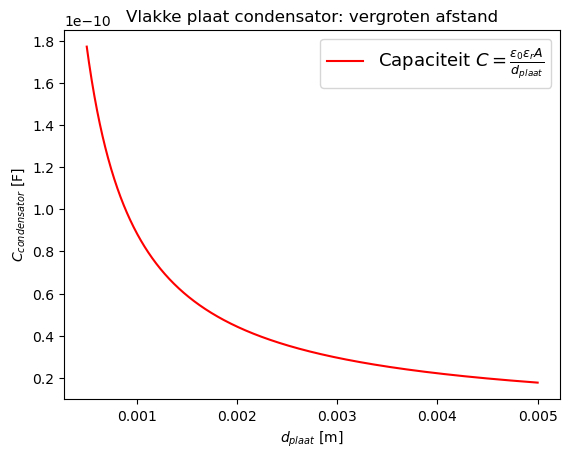

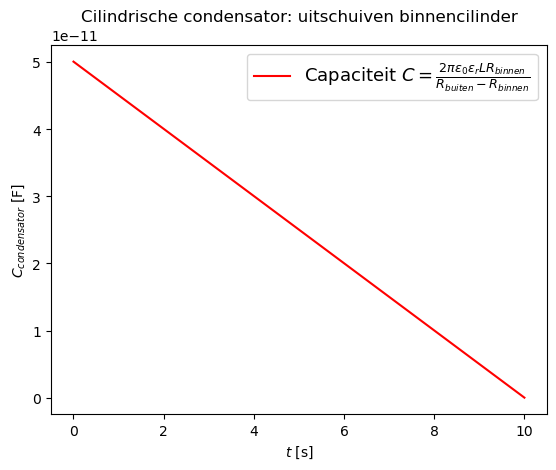

In [25]:
# 1) Capaciteit vlakke plaat condensator, vergroten afstand:
d_plaat = np.linspace(0.5e-3,5e-3,1000) # (m) afstand tussen de platen
A_plaat = 10e-2 * 10e-2 # (m^2) oppervlakte van de plaat
C_plaat = vlakkeplaat(epsilonr_lucht,A_plaat, d_plaat) # (F) 

# Plotten grafiek:
plt.figure()
plt.plot(d_plaat, C_plaat, "r-", label = "Capaciteit $C = \\frac{\\epsilon_0 \\epsilon_r A}{d_{plaat}}$")
plt.title("Vlakke plaat condensator: vergroten afstand")
plt.xlabel("$d_{plaat}$ [m]")
plt.ylabel("$C_{condensator}$ [F]")
plt.legend(fontsize=13)
plt.show()


# 2) Capaciteit cilindrische condensator, uitschuiven binnenste cilinder:
R_binnen = 9e-3/2   # (m) straal van binnencilinder
R_buiten = 10e-3/2  # (m) straal van buitencilinder
L_begin = 10e-2 # (m) lengte van de cilinder op t=0s
tijd = np.linspace(0,10,1000)   # (s) tijd

# Naarmate de tijd toeneemt, neemt de lengte L af. We gaan ervan uit dat de cilinder er met een constante snelheid uitgetrokken wordt.
L = L_begin * (1 - (tijd / 10)) # (m) lengte van de condensator, afhankelijk van de tijd
C_cilinder = cilinder(epsilonr_lucht,L,R_buiten,R_binnen)   # (F) capaciteit 

# Plotten grafiek:
plt.figure()
plt.plot(tijd, C_cilinder, "r-", label = "Capaciteit $C = \\frac{2 \\pi \\epsilon_0 \\epsilon_r L R_{binnen}}{R_{buiten} - R_{binnen}}$")
plt.title("Cilindrische condensator: uitschuiven binnencilinder")
plt.xlabel("$t$ [s]")
plt.ylabel("$C_{condensator}$ [F]")
plt.legend(fontsize=13)
plt.show()

## Stop hier met werken tot na de fysieke ontwerpopdracht in week 3.

### 6) Reflectie opdracht voor na de fysieke ontwerpopdracht


Als het goed is, heeft ieder teamlid van deze simulatie-opdracht een andere opstelling ontworpen hebben tijdens de fysieke ontwerpopdracht. Kies in goed overleg voor deze opdracht een van jullie twee ontwerpen.

Voeg hieronder eerst een foto in van je opstelling die je gekozen hebt.

Jullie gaan in deze opdracht het verschil tussen jullie voorspelde verband en jullie uiteindelijke verkregen kalibratie grafiek proberen te verklaren. Er zijn hiervoor drie mogelijke paden die jullie kunnen kiezen om te onderzoeken, Kies deel a, b of c en werk die volledig uit voor jullie ontwerp. Let op je hoeft er maar een uit te werken.

#### Vraag 6a: Dunne laag niet meegerekende diëlektricum
Deze vraag is goed om te kiezen als je in je ontwerp een kleine laag extra materiaal hebt en deze tijdens de ontwerpopdracht niet hebben meegenomen in je theoretisch kalibratie grafiek.

1. Maak een nieuwe schets van je opstelling waarbij je de dikte van het extra diëlektricum meeneemt.
2. Leid de analytische oplossing af van de capaciteit van de hierboven getekende situatie.
3. Programmeer de analytische oplossing in python.
4. Maak hierna een plot van het kalibratiegrafiek, oude en nieuwe analytische oplossing in een grafiek.
5. Beschrijf en verklaar de verschillen tussen de grafieken.


![Opstelling ontwerpopdracht 2](figures/Opstelling.jpeg)

##### Antwoorden 6a

![Opstelling ontwerpopdracht 2](figures/Schets.jpeg)

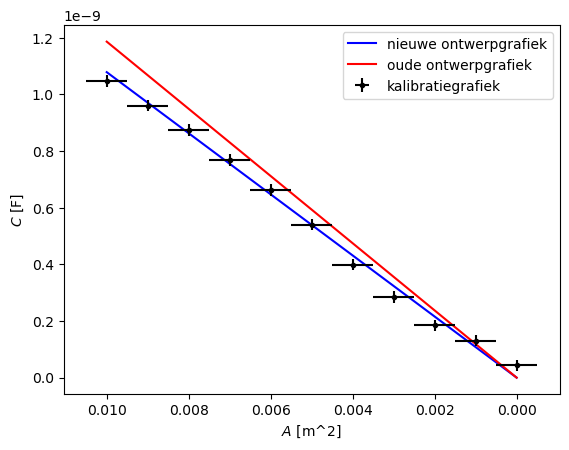

In [26]:
# Functie voor capaciteit van een condensator, uitgaande van 1 dielektisch medium:
def vlakkeplaat(epsilonr,A,d):
    C = (epsilon0 * epsilonr * A) / d     # Afstand tussen de twee platen << oppervlakte A platen. 
    return C

# Specifieke variabelen, die nog niet eerder in dit bestand zijn gedefinieerd:
d_karton = 0.001 # (m) 
epsilonr_karton = 2

# Aanmaken van array, waarbij het oppervlakte van het E-veld lineair afneemt:
A_var = np.linspace(0.01,0,1000) # (m^2) afnemend oppervlakte van 0.01 naar 0.

# Kalibratiemeting, uitgevoerd met arduino:
A_kal = np.array([0.1,0.09,0.08,0.07,0.06,0.05,0.04,0.03,0.02,0.01,0])*0.1  # (m^2)
C_kal = np.array([1047,960.5,874,768,662,540,399,285,185,130,44])*1e-12 # (F)


""" 
Nu gaan we de situatie nog een beschouwen, maar dan door ook het materiaal lucht mee te nemen als significant aanwezige dielektricum. 
In zo'n kartonnen plaatje zit namelijk ook veel ruimte met lucht, waardoor we beter niet enkel van de permittiviteit van karton uit kunnen gaan.

Door de extra laag, kunnen we nu het systeem beschouwen als een parallele plaat condensator, waarvoor geldt:
1/C_totaal = 1/C_karton + 1/C_lucht. Door dit om te schrijven, kan een formule gevonden worden voor de totale capaciteit van de condensator (zie
formule "condensator_extra_laag"). 

Uitgaande van het feit dat de ruimte tussen de twee platen niet volledig uit karton bestaat, moet er een correctie op de dikte d van het 
karton worden uitgevoerd: we nemen aan dat 10% van het karton uit lucht bestaat, ergo 0.0009 m karton en 0.0001 m lucht. 

Met deze gegevens kan een nieuwe berekening voor de capaciteit tegenover het oppervlak worden uitgevoerd.
"""

# Capaciteit-funcite voor condensator bestaande uit 2 dielektra (paralel):
def condensator_extra_laag(epsilonr_1,epsilonr_2,A,d_1,d_2):
    C_extra_laag = (epsilon0 * A) / ((d_1 / epsilonr_1) + (d_2 / epsilonr_2))
    return C_extra_laag


# Plotten van figuren:
plt.figure()
plt.plot(A_var, 6.7*condensator_extra_laag(epsilonr_karton,epsilonr_lucht,A_var,0.0009,0.0001), "b-", label = "nieuwe ontwerpgrafiek")
plt.plot(A_var, 6.7*vlakkeplaat(epsilonr_karton,A_var,d_karton), "r-", label = "oude ontwerpgrafiek")
plt.errorbar(A_kal, C_kal, xerr=0.0005, yerr=2e-11, fmt = "k.", label = "kalibratiegrafiek")
plt.xlabel("$A$ [m^2]")
plt.ylabel("$C$ [F]")
plt.legend()
plt.gca().invert_xaxis()
plt.show()


"""
Zoals in de code van het plotten van de grafiekente zien is, wordt een factor 6.7 meegenomen in het plotten van de ontwerpgrafieken. De reden 
hiervoor is een error die zich voor heeft gedaan in de kalibratiemetingen, die door het toevoegen van de factor gecompenseerd wordt. Voor nadere
informatie, zie ontwerpopdracht 2 (Emma Jule Drent).
"""
print()


##### Antwoorden 6a

Zoals we zien, is de nieuwe ontwerpgrafiek t.o.v. van sde initiele grafiek, veel beter aansluitend op de kalibratiegrafiek gemeten met de arduino. Daar waar het oppervlakte de 0 nadert, zie je dat de twee grafieken steeds dichter op elkaar komen te liggen. (Logisch, want voor A=0, geldt natuurlijk C=0, in beide gevallen).

De nieuwe grafiek stelt een lager maximum capaciteit dan de oude. Dit komt omdat $\epsilon_{lucht} < \epsilon_{karton}$. Voor de condensator wordt als het ware netto dan een lagere epsilon genomen, waaruit een lagere capaciteit volgt. 

#### Vraag 6b1: Lading op een condensator met het edge effect meegenomen

In deze opdracht gaan we verder in op het Edge effect en de invloed daarvan op de praktische capaciteit. Deze opdracht bouwt voort op de vraag 4.3.
Jullie hebben tijdens de ontwerpopdracht vierkante platen gebruikt in tegenstelling tot de ronde platen waarvoor de factoren in figure[label] zijn afgeleid. Er is onderzoek gedaan naar de factoren waarmee de praktische capaciteit vergeleken met de daadwerkelijke capaciteit verschilt dat onderzoek vind je hier: https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=311759. Zoek in het onderzoek tabel 1 en formules 22 en 36 op.

1. Vergelijk de factor waarmee de schijf(disk) condensator verschilt met die van de vierkante plaat, kunnen we de vierkante plaat factor benaderen met de factor voor een disk condensator? Vergelijk het procentuele verschil tussen de factoren van de circulaire en vierkante platen, met de onzekerheden die in de meting zitten.



##### Antwoord 6b1

*Vergelijk hier de factoren tussen de circulaire en vierkante vlakke plaat condensatoren.*

#### Vraag 6b2: Capaciteit van een condensator met het edge effect meegenomen

Vanaf hier nemen we aan dat factor van de circulaire platen ongeveer gelijk is aan de factor voor vierkante platen. De factor die de capaciteit van de vlakke plaat approximatie linkt aan de werkelijke capaciteit noemen we vanaf nu de idealiteitsfactor.

1. Bereken de daadwerkelijke theoretische capaciteit van de condensator uit de sanity check 3 van de fysieke ontwerpopdracht en print deze op een nette manier.
2. Vergelijk dit met de daadwerkelijke theoretische capaciteit met de capaciteit die je op de dag zelf hebt gemeten.

Vanaf hier gaan we verder met jullie sensor van de ontwerpopdracht "Maak een sensor met condensatoren":

3. Reken je theoretische kalibratie grafiek om met de idealiteitsfactor.
4. Vergelijk je nieuwe theoretische kalibratiegrafiek van je praktische kalibratiegrafiek van de dag zelf.

In [27]:
# Schrijf hier jouw code die de vlakke plaat capaciteit omschrijft naar de werkelijke capaciteit

# def C_niet_ideaal(#relevante parameters):
    # Jouw berekeningen


##### Antwoorden 6b2

*Doe in deze markdown cel je vergelijkingen voor de sanity check condensator en je kalibratiegrafiek.*

#### Vraag 6c: Niet linear diëlektricum optie 1

Niet alle materialen zijn een lineair diëlektricum. Een aantal van de materialen die sterk niet lineair gedrag vertonen zijn: sponzen, foam & rubber. Als je in je opdracht een materiaal gebruikt heb waarvan je verwacht dat het verband sterk niet lineair is kan dit een hele goede opdracht zijn.
| Materiaal |$\chi_2$   |
| :-------------|:-------------|
| Spons|  |

Als jouw materiaal hier niet tussen staat dan kan je zelf op zoek naar een waarde van $\chi_2$ in de literatuur.

#### Vraag 6c1

1. Leidt het D veld van de condensator af uit de wet van Gauss.
2. Vindt een analytische uitdrukking voor het elektrisch veld in termen van het D veld.

##### Antwoorden 6c 1
    

#### Vraag 6c2

1. Programmeer je oplossingen voor het D en E veld in python, gebruik het D veld uit je fysieke ontwerpopdracht.

Als je het elektrische veld van een vierkante vlakke plaat condensator weet kan je de capaciteit berekenen met de onderstaande formule:
$C = \frac{A
E_z \epsilon_0}{\Delta V}$

2. Plot de capaciteit van het niet lineaire diëlektricum, het theoretische kalibratiegrafiek en de uiteindelijke kalibratiegrafiek van de fysieke ontwerpopdracht.
3. Verklaar verschillen tussen de grafieken.

#### Vraag 7

Hoeveel van de afwijking tussen je metingen en je oorspronkelijke voorspelde kalibratiegrafiek wordt verklaard door wat je bij vraag 6 hebt uitgerekend? Kan je een (aantal) elektrisch veld en capaciteit gerelateerde reden(en) verzinnen wat de rest van de afwijking tussen meting en voorspelde kalibratiegrafiek kan verklaren.

##### Antwoorden 7

De gemiddelde afwijking tussen de metingen en de oorspronkelijk voorspelde kalibratiegrafiek is gegeven door de formule:

$$
\frac{1}{n}\sum_{i=1}^{n}\left|\hat{y}_i-y_i\right|
$$

dit geeft een afwijking van:

- $\mathrm{Afwijking}$ (oud model): $\approx 70\,\text{pF}$

Dezelfde formule gebruikt voor de afwijking tussen de metingen en de nieuwe voorspelde kalibratiegrafiek geeft een afwijking van:

- $\mathrm{Afwijking}$ (nieuw model): $\approx 21\,\text{pF}$

Dat geeft ongeveer 70% minder afwijking door het meenemen van de extra laag.
 
De rest van de afwijking kan verklaard worden door de volgende redenen:

1. edge effecten: Door de eindige plaatgrootte treedt het edge effect op bij de randen. De capaciteitsformule gaat uit van een uniform veld over een oneindig grote plaat. In werkelijkheid buigt het veld om de randen naar buiten. 
2. Platen niet perfect parallel: Als de platen niet perfect parallel ten opzichte van elkaar liggen, kan dit zorgen voor een varierende plaatafstand (d) op verschillende plekken op de plaat. Dit kan zorgen zorgen voor afwijkende data bij het meten.
3. Non lineair diëlektricum: epsilon_r kan bij karton variëren door de invloed van vocht of temperatuur op het karton.
4. Niet ideaal cirquit: De theorie gaat uit van een ideaal cirquit, waarin de resterende onderdelen een capaciteit van 0 hebben. Echter kunnen bijvoorbeeld draden of de arduino ingang een ongewenste capaciteit hebben die wordt meegenomen in de totale capaciteit.
